# Model Optimization
----------------

Now that we have a couple of forecast models, we can discuss parameter optimization. Let's recap the models we have seen so far and their different parameters.

* **Moving average**, n
* **Simple exponential smoothing**, alpha
* **Double exponential smoothing**, alpha, beta

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 😎 `simple_exp_smooth` and `double_exp_smooth`
Here are the two functions we worked through previously.

In [2]:
def simple_exp_smooth(d, extra_periods=1, alpha=0.4):

  # Transform the input into a numpy array
  d = np.array(d)
  # Historical period length
  cols = len(d)
  # Append np.nan into the demand array to cover future periods
  d = np.append(d, [np.nan]*extra_periods)

  # Forecast array
  f = np.full(cols + extra_periods, np.nan)
  # initialization of first forecast
  f[1] = d[0]

  # Create all the t+1 forecasts until end of historical period
  for t in range(2,cols+1):
    f[t] = alpha*d[t-1] + (1-alpha)*f[t-1]
  # Forecast for all extra periods
  f[cols+1:] = f[t]

  df = pd.DataFrame.from_dict({'Demand':d, 'Forecast':f, 'Error':d-f})
  return df

In [3]:
def double_exp_smooth(d, extra_periods=1, alpha=0.4, beta=0.4):
  # transform the data into a numpy array
  d = np.array(d)
  # historical period lengths
  cols = len(d)
  # append nan into the demand array to cover future periods
  d = np.append(d,[np.nan]*extra_periods)

  # creation of the level, trend and forecast arrays
  f, a, b = np.full((3,cols+extra_periods), np.nan)

  # level and trend initialization
  a[0] = d[0]
  b[0] = d[1] - d[0]

  # create all the t+1 forecasts
  for t in range(1,cols):
    f[t] = a[t-1] + b[t-1]
    a[t] = alpha*d[t] + (1-alpha)*(a[t-1] + b[t-1])
    b[t] = beta*(a[t] - a[t-1]) + (1-beta)*b[t-1]

  # forecast for all extra periods
  for t in range(cols, cols+extra_periods):
    f[t] = a[t-1] + b[t-1]
    a[t] = f[t]
    b[t] = b[t-1]

  df = pd.DataFrame.from_dict({"Demand":d,
                               "Forecast": f,
                               "Level" : a,
                               "Trend" : b,
                               "Error" : d-f})
  return df

# 🤖`exp_smooth_opti`

In [4]:
ar = np.array([1,2,3,4,-20])
np.argmin(ar) # remember, python counts from 0!

4

In [5]:
ar[4]

-20

In [16]:
def exp_smooth_opti(d, extra_periods=6):

  param=[] # contains the different parameters set
  KPI=[] # constains the results of each model
  outputs=[] # contains all the dataframes returned by the different models

  #for alpha in [0.05,0.1,0.2,0.3,0.4,0.5,0.6]: # take bigger steps!
  for alpha in np.arange(0.05,0.8,0.01): # take smaller steps!
    #print('alpha:', alpha)
    #print('----------------------------')
    df = simple_exp_smooth(d, extra_periods=extra_periods, alpha=alpha)
    param.append("Simple Smoothing, alpha: " + str(alpha))
    outputs.append(df)
    MAE = df['Error'].abs().mean()
    KPI.append(MAE)


    #for beta in [0.05,0.1,0.2,0.3,0.4]:
    for beta in np.arange(0.05,0.8,0.01):
      #print('beta:', beta)
      df = double_exp_smooth(d, extra_periods=extra_periods, alpha=alpha, beta=beta)
      param.append("Double Exponential Smoothing, alpha: " + str(alpha) + ", beta: " + str(beta))
      outputs.append(df)
      MAE = df['Error'].abs().mean()
      KPI.append(MAE)
    #print('-------------')


  mini = np.argmin(KPI)
  print("Best Solution found for ", param[mini], "MAE of", round(KPI[mini],2))

  return outputs[mini]

# 🦾Playing with our function
Corresponds to the textbook example.

Best Solution found for  Simple Smoothing, alpha: 0.4100000000000001 MAE of 2.74


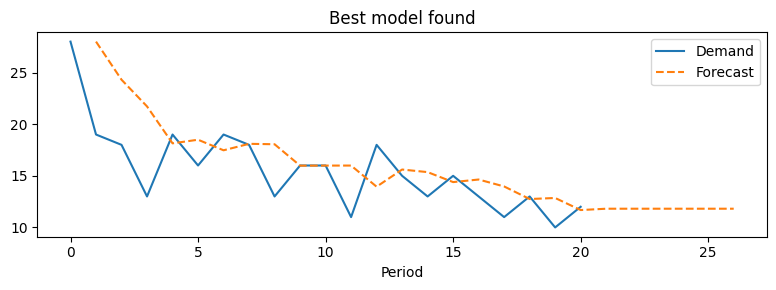

In [17]:
d = [28,19,18,13,19,16,19,18,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = exp_smooth_opti(d)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),
                               title='Best model found',
                               style=['-','--'])

plt.tight_layout()

In [15]:
df

,Demand,Forecast,Error
Period,,,
0,28.0,NaN,NaN
1,19.0,28.000000,-9.000000
2,18.0,24.400000,-6.400000
3,13.0,21.840000,-8.840000
4,19.0,18.304000,0.696000
5,16.0,18.582400,-2.582400
6,19.0,17.549440,1.450560
7,18.0,18.129664,-0.129664
8,13.0,18.077798,-5.077798


## 🦾What about using RMSE instead?

## 🦾 Try it on some new data!